### Загрузка данных через системные утилиты (Bash)

Используем утилиту `wget` для загрузки сырых данных. 
- Флаг `-c` (continue) позволяет возобновить загрузку при обрыве связи.
- Флаг `-P` указывает директорию для сохранения.

In [21]:
# # Создаем директорию для данных
# !mkdir -p data

# # Скачиваем логи взаимодействий (Reviews)
# !wget -c -P data https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Electronics.jsonl.gz

# # Скачиваем метаданные товаров (Metadata)
# !wget -c -P data https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Electronics.jsonl.gz

In [22]:
# pip install git+https://github.com/daviddavo/lightfm

In [23]:
import os
import json
import gzip
import numpy as np
import pandas as pd
from typing import Tuple, List, Dict, Any
from scipy import sparse
from lightfm.data import Dataset
from tqdm import tqdm

pd.set_option('display.max_columns', None)

## Шаг 1. Подготовка данных

Загружаем набор данных Amazon. Нам потребуются два файла:
1. `Electronics_5.json.gz`  — содержит матрицу взаимодействий (user -> item -> rating).
2. `meta_Electronics.json.gz` — содержит контентные признаки товаров (жанры, категории, бренды).

In [ ]:
import gzip
import json
import pandas as pd
from typing import Tuple

def load_amazon_data(reviews_path: str, meta_path: str, max_reviews: int = 500_000) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Загружает и объединяет данные о рейтингах и метаданных.
    Используется потоковое чтение и ранняя фильтрация метаданных для экономии RAM.
    """
    print(f"Загрузка отзывов (ограничение: {max_reviews} строк для скорости)..." if max_reviews>0 else "Загрузка всех отзывов без ограничений")
    reviews = []
    # Используем 'rt' (read text) для корректного чтения строк из архива
    with gzip.open(reviews_path, 'rt', encoding='utf-8') as f:
        for i, line in tqdm(enumerate(f)):
            if i >= max_reviews and max_reviews>0:
                break
            data = json.loads(line)
            
            # Поддержка новой схемы Amazon 2023 ('user_id', 'parent_asin', 'rating')
            # Fallback (or) позволяет коду работать и на старых датасетах
            user_id = data.get('user_id') or data.get('reviewerID')
            item_id = data.get('parent_asin') or data.get('asin')
            rating = data.get('rating') or data.get('overall')
            
            if user_id and item_id and rating is not None:
                reviews.append({
                    'user_id': user_id,
                    'item_id': item_id,
                    'rating': float(rating)
                })
                
    df_reviews = pd.DataFrame(reviews)
    
    # Множество уникальных товаров из считанных отзывов 
    # [Complexity: O(1) на поиск]
    valid_items_from_reviews = set(df_reviews['item_id'])
    
    print(f"Загрузка метаданных (только для {len(valid_items_from_reviews)} нужных товаров)...")
    metadata = []
    with gzip.open(meta_path, 'rt', encoding='utf-8') as f:
        for line in tqdm(f):
            data = json.loads(line)
            item_id = data.get('parent_asin') or data.get('asin')
            
            # Парсим json только если товар реально есть в наших логах
            if item_id in valid_items_from_reviews:
                categories = data.get('categories') or data.get('category', [])
                # В версии 2023 года categories - это плоский список строк
                if categories and isinstance(categories[0], list):
                    flat_categories = [cat for sublist in categories for cat in sublist]
                else:
                    flat_categories = categories
                
                metadata.append({
                    'item_id': item_id,
                    'brand': data.get('brand', 'unknown_brand'),
                    'categories': flat_categories
                })
                
    df_meta = pd.DataFrame(metadata)
    
    # Окончательная синхронизация (удаляем товары из отзывов, для которых не нашлось меты)
    valid_item_ids = set(df_reviews['item_id']).intersection(set(df_meta['item_id']))
    df_reviews = df_reviews[df_reviews['item_id'].isin(valid_item_ids)]
    df_meta = df_meta[df_meta['item_id'].isin(valid_item_ids)].drop_duplicates(subset=['item_id'])
    
    return df_reviews, df_meta

REVIEWS_FILE = 'data/Electronics.jsonl.gz'
META_FILE = 'data/meta_Electronics.jsonl.gz'

df_reviews, df_meta = load_amazon_data(REVIEWS_FILE, META_FILE, max_reviews=-1)

print(f"Размер датасета взаимодействий: {df_reviews.shape[0]} строк")
print(f"Уникальных пользователей: {df_reviews['user_id'].nunique()}")
print(f"Уникальных товаров: {df_reviews['item_id'].nunique()}")

In [ ]:
def filter_k_core(df: pd.DataFrame, user_col: str = 'user_id', item_col: str = 'item_id', min_user_interactions: int = 5, min_item_interactions: int = 5) -> pd.DataFrame:
    """
    Оставляет в датасете только тех пользователей и те товары, 
    у которых есть как минимум заданное число взаимодействий.
    Выполняется итеративно, так как удаление пользователей может 
    уменьшить число оценок у товаров, и наоборот.
    """
    print(f"Исходный размер датасета: {df.shape[0]} строк")
    
    while True:
        start_shape = df.shape[0]
        
        # Шаг 1: Фильтрация пользователей
        user_counts = df[user_col].value_counts()
        valid_users = user_counts[user_counts >= min_user_interactions].index
        df = df[df[user_col].isin(valid_users)]
        
        # Шаг 2: Фильтрация товаров
        item_counts = df[item_col].value_counts()
        valid_items = item_counts[item_counts >= min_item_interactions].index
        df = df[df[item_col].isin(valid_items)]
        
        # Если размер датасета перестал меняться, значит мы достигли k-core состояния
        if df.shape[0] == start_shape:
            break
            
    print(f"Размер после {min_user_interactions}-core фильтрации: {df.shape[0]} строк")
    return df

# Применяем фильтр к нашему сырому датасету перед созданием матриц
KORE_N = 20
df_reviews_filtered = filter_k_core(df_reviews, min_user_interactions=KORE_N, min_item_interactions=KORE_N)

# Важно: после фильтрации отзывов, нужно снова синхронизировать метаданные товаров,
# чтобы не передавать в LightFM признаки для товаров, которые мы удалили.
valid_filtered_items = set(df_reviews_filtered['item_id'])
df_meta_filtered = df_meta[df_meta['item_id'].isin(valid_filtered_items)]

print(f"Уникальных пользователей осталось: {df_reviews_filtered['user_id'].nunique()}")
print(f"Уникальных товаров осталось: {df_reviews_filtered['item_id'].nunique()}")

Исходный размер датасета: 43886942 строк
Размер после 20-core фильтрации: 298309 строк
Уникальных пользователей осталось: 10507
Уникальных товаров осталось: 5457


### Создание маппингов (LightFM Dataset)

Библиотека `LightFM` строго требует, чтобы идентификаторы пользователей и товаров были последовательными `int` (0, 1, 2...). 
Класс `Dataset` собирает уникальные значения из наших данных и формирует внутренние словари сопоставления.

Кроме того, мы сформируем признаки товаров (Item Features). Мы преобразуем бренды и категории в строковый формат признака (например, `brand:apple`, `category:camera`), чтобы алгоритм мог выучить их эмбеддинги.

In [ ]:
from lightfm.data import Dataset
import pandas as pd

# Явно копируем отфильтрованные данные, чтобы избежать путаницы ссылок
final_reviews = df_reviews_filtered.copy()
final_meta = df_meta_filtered.copy()

# Защита от ошибки (Sanity Check)
assert final_reviews['user_id'].nunique() < 100_000, "Ошибка: В маппинг попал сырой датасет вместо отфильтрованного!"

print("Сбор уникальных признаков из метаданных...")
all_item_features = set()
for _, row in final_meta.iterrows():
    all_item_features.add(f"brand:{row['brand']}")
    for cat in row['categories']:
        all_item_features.add(f"category:{cat}")

all_item_features = list(all_item_features)

# 1. Обучение маппера 
dataset = Dataset()
dataset.fit(
    users=final_reviews['user_id'].unique(),
    items=final_reviews['item_id'].unique(), 
    item_features=all_item_features
)

num_users, num_items = dataset.interactions_shape()
print(f"Размерность маппинга: {num_users} пользователей x {num_items} товаров")

# 2. Построение матрицы взаимодействий
print("Построение матрицы взаимодействий...")
interactions_matrix, weights_matrix = dataset.build_interactions(
    (row['user_id'], row['item_id'], row['rating']) 
    for _, row in final_reviews.iterrows()
)

sparsity = 100 * (1 - interactions_matrix.nnz / (num_users * num_items))
print(f"Разреженность матрицы: {sparsity:.4f}% (ожидаем около 99%, что отлично для DL)")

# 3. Построение матрицы признаков товаров
print("Построение матрицы признаков товаров...")
def generate_item_features(meta_df: pd.DataFrame):
    for _, row in meta_df.iterrows():
        features = [f"brand:{row['brand']}"] + [f"category:{cat}" for cat in row['categories']]
        yield (row['item_id'], features)

item_features_matrix = dataset.build_item_features(generate_item_features(final_meta))
print(f"Размерность матрицы признаков товаров: {item_features_matrix.shape}")

Сбор уникальных признаков из метаданных...
Размерность маппинга: 10507 пользователей x 5457 товаров
Построение матрицы взаимодействий...
Разреженность матрицы: 99.4797% (ожидаем около 99%, что отлично для DL)
Построение матрицы признаков товаров...
Размерность матрицы признаков товаров: (5457, 6032)


## Шаг 2. Обучение модели (WARP Loss)

Перед обучением мы разделяем матрицу взаимодействий на обучающую и тестовую выборки.
Используем встроенную функцию `random_train_test_split` из LightFM. Она маскирует часть взаимодействий (переводит их в 0 в матрице `train`), оставляя их только в `test`.

Мы инициализируем гибридную модель LightFM.
Она выучит латентные векторы (эмбеддинги) для пользователей и признаков товаров.
Вектор товара будет представлять собой сумму эмбеддингов его признаков (id, brand, categories).

In [ ]:
import numpy as np
from lightfm import LightFM
from lightfm.cross_validation import random_train_test_split

# 1. Разделение выборки (80% Train / 20% Test)
# Важно: test_percentage=0.2 означает, что 20% ненулевых элементов матрицы 
# перейдут в test, а в train на их месте будут нули.
train_interactions, test_interactions = random_train_test_split(
    interactions_matrix, 
    test_percentage=0.2, 
    random_state=42
)

print(f"Взаимодействий в Train: {train_interactions.nnz}")
print(f"Взаимодействий в Test: {test_interactions.nnz}")

# 2. Инициализация модели LightFM
# Гиперпараметры взяты базовые, позже в задании (п. 5.1) будет их оптимизация
model = LightFM(
    no_components=32,       # Размерность латентных векторов (Embeddings)
    loss='warp',            # Pairwise функция потерь (как требует задание)
    learning_rate=0.05,     # Шаг градиентного спуска
    random_state=42
)

# 3. Обучение модели
# epochs=10 для прототипа. num_threads настраивайте под свой процессор
print("Начинаем обучение модели...")
model.fit(
    train_interactions,
    item_features=item_features_matrix,
    epochs=10, 
    num_threads=32, # [Укажите количество ядер вашего CPU для ускорения]
    verbose=True
)
print("Обучение завершено.")

Взаимодействий в Train: 238647
Взаимодействий в Test: 59662
Начинаем обучение модели...


Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 100%|██████████| 10/10 [07:04<00:00, 42.40s/it]

Обучение завершено.


## Шаг 3. Генерация рекомендаций (Top-N)

Для получения рекомендаций мы используем метод `model.predict()`. 
Важный нюанс: `LightFM` работает с внутренними целочисленными идентификаторами (от 0 до N). Поэтому перед выдачей рекомендаций мы должны сделать обратное преобразование (Reverse Mapping): из внутренних индексов обратно в строковые `item_id` (ASIN) датасета Amazon, чтобы показать реальные метаданные (категории и бренды).

Мы сгенерируем Топ-5 рекомендаций для 5 случайных пользователей, исключив товары, которые они уже оценивали в обучающей выборке (Train).

In [ ]:
import numpy as np
import pandas as pd
from typing import List, Dict

# 1. Извлекаем внутренние словари маппинга из нашего объекта dataset
user_id_map, user_feature_map, item_id_map, item_feature_map = dataset.mapping()

# Создаем обратный словарь для товаров (Внутренний ID -> Внешний ID 'B00...')
inv_item_id_map = {internal_id: external_id for external_id, internal_id in item_id_map.items()}

# Создаем быстрый справочник метаданных для красивого вывода
# key: item_id (внешний), value: dict(brand, categories)
item_meta_dict = final_meta.set_index('item_id').to_dict(orient='index')

def get_recommendations(
    model, 
    user_ext_id: str, 
    dataset_mapping: tuple, 
    train_matrix, 
    item_features, 
    num_recs: int = 5
) -> None:
    """
    Генерирует Топ-N рекомендаций для конкретного пользователя.
    """
    user_map, _, item_map, _ = dataset_mapping
    
    # Переводим внешний ID пользователя во внутренний
    if user_ext_id not in user_map:
        print(f"Пользователь {user_ext_id} не найден в словаре.")
        return
        
    user_int_id = user_map[user_ext_id]
    num_items = len(item_map)
    
    # 1. Вычисляем скоры для ВСЕХ товаров [Размерность: Num_Items]
    # Обязательно передаем item_features!
    scores = model.predict(
        user_ids=user_int_id, 
        item_ids=np.arange(num_items), 
        item_features=item_features
    )
    
    # 2. Находим товары, с которыми пользователь уже взаимодействовал
    # train_matrix у нас в формате COO, переводим в CSR для быстрого доступа по строке
    train_csr = train_matrix.tocsr()
    known_items_int = train_csr[user_int_id].indices
    
    # 3. Исключаем известные товары, заменяя их скор на минус бесконечность
    scores[known_items_int] = -np.inf
    
    # 4. Получаем индексы Топ-N товаров с максимальным скором
    # argsort сортирует по возрастанию, поэтому берем с конца [::-1]
    top_items_int = np.argsort(scores)[-num_recs:][::-1]
    
    # Вывод результатов
    print(f"\nПользователь: {user_ext_id} (Внутренний ID: {user_int_id})")
    print("-" * 50)
    print("Уже взаимодействовал с (примеры):")
    for item_int in known_items_int[:3]: # покажем до 3-х известных товаров
        ext_id = inv_item_id_map[item_int]
        meta = item_meta_dict.get(ext_id, {})
        print(f" - [{ext_id}] Бренд: {meta.get('brand', 'N/A')} | Категории: {meta.get('categories', [])[:2]}")
        
    print("\nТОП Рекомендаций:")
    for rank, item_int in enumerate(top_items_int, 1):
        ext_id = inv_item_id_map[item_int]
        meta = item_meta_dict.get(ext_id, {})
        print(f" {rank}. [{ext_id}] Бренд: {meta.get('brand', 'N/A')} | Категории: {meta.get('categories', [])[:2]}")
    print("=" * 50)

# 2. Выбираем 5 случайных пользователей из словаря для проверки
np.random.seed(42)
random_users_ext = np.random.choice(list(user_id_map.keys()), size=5, replace=False)

# 3. Генерируем рекомендации
for user in random_users_ext:
    get_recommendations(
        model=model, 
        user_ext_id=user, 
        dataset_mapping=dataset.mapping(),
        train_matrix=train_interactions, 
        item_features=item_features_matrix, 
        num_recs=5
    )


Пользователь: AF2V7OSXK7IWC3NRWH33YPZYYQBQ (Внутренний ID: 8985)
--------------------------------------------------
Уже взаимодействовал с (примеры):
 - [B01C6ESQM6] Бренд: unknown_brand | Категории: ['Electronics', 'Home Audio']
 - [B0BN74ZJDK] Бренд: unknown_brand | Категории: ['Electronics', 'Computers & Accessories']
 - [B00IQBSW28] Бренд: unknown_brand | Категории: ['Electronics', 'Computers & Accessories']

ТОП Рекомендаций:
 1. [B00EZMZULI] Бренд: unknown_brand | Категории: ['Electronics', 'Computers & Accessories']
 2. [B0BMQJYLQV] Бренд: unknown_brand | Категории: ['Electronics', 'Computers & Accessories']
 3. [B0BHWQ3H17] Бренд: unknown_brand | Категории: ['Electronics', 'Computers & Accessories']
 4. [B00O1RTQJE] Бренд: unknown_brand | Категории: ['Electronics', 'Computers & Accessories']
 5. [B088C3ZJHV] Бренд: unknown_brand | Категории: ['Electronics', 'Computers & Accessories']

Пользователь: AGK4AJBAX2ZULP7EVXQITMDOUGSQ (Внутренний ID: 565)
-----------------------------

## Шаг 4. Оценка модели: 
- Оцените производительность модели, используя метрики precision@k, recall@k и AUC. 
- Проверьте результаты как на обучающем, так и на тестовом наборах данных. 

In [ ]:
from lightfm.cross_validation import random_train_test_split
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
from lightfm import LightFM

# 1. Удаляем дубликаты взаимодействий (Оставляем только одну оценку на пару User-Item)
final_reviews_unique = final_reviews.drop_duplicates(subset=['user_id', 'item_id']).copy()
duplicates_dropped = len(final_reviews) - len(final_reviews_unique)
print(f"Найдено и удалено дубликатов: {duplicates_dropped}")

# 2. Перестраиваем матрицу взаимодействий из очищенных данных
# (Словарь dataset переучивать не нужно, так как уникальные ID не изменились)
print("Перестроение матрицы взаимодействий...")
interactions_matrix, weights_matrix = dataset.build_interactions(
    (row['user_id'], row['item_id'], row['rating']) 
    for _, row in final_reviews_unique.iterrows()
)

# 3. Делим данные заново (теперь пересечений быть не может)
print("Разделение на Train/Test...")
train_interactions, test_interactions = random_train_test_split(
    interactions_matrix, 
    test_percentage=0.2, 
    random_state=42
)

# 4. Инициализация и обучение модели
print("Обучение модели (WARP)...")
model = LightFM(
    no_components=32, 
    loss='warp', 
    learning_rate=0.05, 
    random_state=42
)

model.fit(
    train_interactions,
    item_features=item_features_matrix,
    epochs=10, 
    num_threads=4, # Используем 4 потока, чтобы не "душить" процессор
    verbose=True
)

# 5. Вычисление метрик (Оптимизированное)
print("Вычисление метрик на тестовой выборке...")
test_precision = precision_at_k(
    model, 
    test_interactions, 
    train_interactions=train_interactions, 
    item_features=item_features_matrix, 
    k=10,
    num_threads=4
).mean()

test_recall = recall_at_k(
    model, 
    test_interactions, 
    train_interactions=train_interactions, 
    item_features=item_features_matrix, 
    k=10,
    num_threads=4
).mean()

test_auc = auc_score(
    model, 
    test_interactions, 
    train_interactions=train_interactions, 
    item_features=item_features_matrix,
    num_threads=4
).mean()

print("\n--- Финальные результаты ---")
print(f"Test Precision@10:  {test_precision:.4f}")
print(f"Test Recall@10:     {test_recall:.4f}")
print(f"Test AUC:           {test_auc:.4f}")

Найдено и удалено дубликатов: 10038
Перестроение матрицы взаимодействий...
Разделение на Train/Test...
Обучение модели (WARP)...


Epoch: 100%|██████████| 10/10 [00:47<00:00,  4.72s/it]


Вычисление метрик на тестовой выборке...

--- Финальные результаты ---
Test Precision@10:  0.0206
Test Recall@10:     0.0390
Test AUC:           0.7384


## Шаг 5. Улучшения

### Оптимизация гиперпараметров (Random Search)

In [ ]:
import random
import itertools
import pandas as pd
from lightfm import LightFM
from lightfm.evaluation import precision_at_k
from IPython.display import display

# 1. Задаем сетку параметров согласно заданию
param_grid = {
    'no_components': [16, 32, 64, 128],
    'learning_rate': [0.01, 0.05, 0.1],
    'loss': ['warp', 'bpr', 'logistic']
}

# 2. Генерируем все возможные комбинации (36 вариантов)
keys, values = zip(*param_grid.items())
all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

# 3. Random Search: выбираем 10 случайных конфигураций для экономии времени
# (В production можно увеличить n_iter)
random.seed(42)
n_iter = 10
sampled_combinations = random.sample(all_combinations, n_iter)

print(f"Запуск Random Search для {n_iter} комбинаций...\n")

results = []
best_precision = 0.0
best_params = None
best_model = None

# 4. Цикл поиска
for i, params in enumerate(sampled_combinations, 1):
    print(f"Итерация {i}/{n_iter} | Параметры: {params}")
    
    # Инициализация новой модели с текущими параметрами
    model_cv = LightFM(
        no_components=params['no_components'],
        learning_rate=params['learning_rate'],
        loss=params['loss'],
        random_state=42
    )
    
    # Обучение (5 эпох для ускорения поиска, обычно этого хватает для понимания тренда)
    model_cv.fit(
        train_interactions,
        item_features=item_features_matrix,
        epochs=5,
        num_threads=4,
        verbose=False # Отключаем progress bar для чистоты вывода
    )
    
    # Оценка (используем только Test Precision@10, как требует задание)
    score = precision_at_k(
        model_cv, 
        test_interactions, 
        train_interactions=train_interactions, 
        item_features=item_features_matrix, 
        k=10, 
        num_threads=4
    ).mean()
    
    print(f" -> Test Precision@10: {score:.4f}")
    
    # Сохраняем результат
    results.append({
        'no_components': params['no_components'],
        'learning_rate': params['learning_rate'],
        'loss': params['loss'],
        'precision_at_10': score
    })
    
    # Обновляем лучший результат
    if score > best_precision:
        best_precision = score
        best_params = params
        best_model = model_cv

# 5. Анализ результатов
print("\n" + "="*50)
print(f"Лучшая точность (Precision@10): {best_precision:.4f}")
print(f"Лучшие гиперпараметры: {best_params}")

# Создаем DataFrame для визуального анализа (сортируем по убыванию качества)
df_results = pd.DataFrame(results).sort_values(by='precision_at_10', ascending=False)
display(df_results)

Запуск Random Search для 10 комбинаций...

Итерация 1/10 | Параметры: {'no_components': 16, 'learning_rate': 0.1, 'loss': 'bpr'}
 -> Test Precision@10: 0.0073
Итерация 2/10 | Параметры: {'no_components': 16, 'learning_rate': 0.01, 'loss': 'bpr'}
 -> Test Precision@10: 0.0073
Итерация 3/10 | Параметры: {'no_components': 32, 'learning_rate': 0.1, 'loss': 'logistic'}
 -> Test Precision@10: 0.0008
Итерация 4/10 | Параметры: {'no_components': 32, 'learning_rate': 0.1, 'loss': 'warp'}
 -> Test Precision@10: 0.0209
Итерация 5/10 | Параметры: {'no_components': 32, 'learning_rate': 0.05, 'loss': 'logistic'}
 -> Test Precision@10: 0.0008
Итерация 6/10 | Параметры: {'no_components': 16, 'learning_rate': 0.05, 'loss': 'bpr'}
 -> Test Precision@10: 0.0072
Итерация 7/10 | Параметры: {'no_components': 64, 'learning_rate': 0.05, 'loss': 'logistic'}
 -> Test Precision@10: 0.0008
Итерация 8/10 | Параметры: {'no_components': 16, 'learning_rate': 0.05, 'loss': 'warp'}
 -> Test Precision@10: 0.0195
Итераци

,no_components,learning_rate,loss,precision_at_10
3,32,0.10,warp,0.020861
8,64,0.05,warp,0.019823
7,16,0.05,warp,0.019525
1,16,0.01,bpr,0.007303
0,16,0.10,bpr,0.007284
5,16,0.05,bpr,0.007236
2,32,0.10,logistic,0.000836
4,32,0.05,logistic,0.000836
6,64,0.05,logistic,0.000836
9,128,0.01,logistic,0.000836


Запуск тестирования регуляризации (параметры: 32 факторов, lr=0.1)...
Внимание: Вычисление Train Precision требует времени. Пожалуйста, подождите.

Alpha: 0.0    | Train Prec: 0.1070 | Test Prec: 0.0215 | Gap: 0.0854 (466.1 сек)
Alpha: 0.0001 | Train Prec: 0.1112 | Test Prec: 0.0225 | Gap: 0.0887 (465.8 сек)
Alpha: 0.001  | Train Prec: 0.0721 | Test Prec: 0.0179 | Gap: 0.0542 (467.3 сек)
Alpha: 0.01   | Train Prec: 0.0052 | Test Prec: 0.0008 | Gap: 0.0044 (463.8 сек)
Alpha: 0.1    | Train Prec: 0.0041 | Test Prec: 0.0006 | Gap: 0.0036 (471.3 сек)


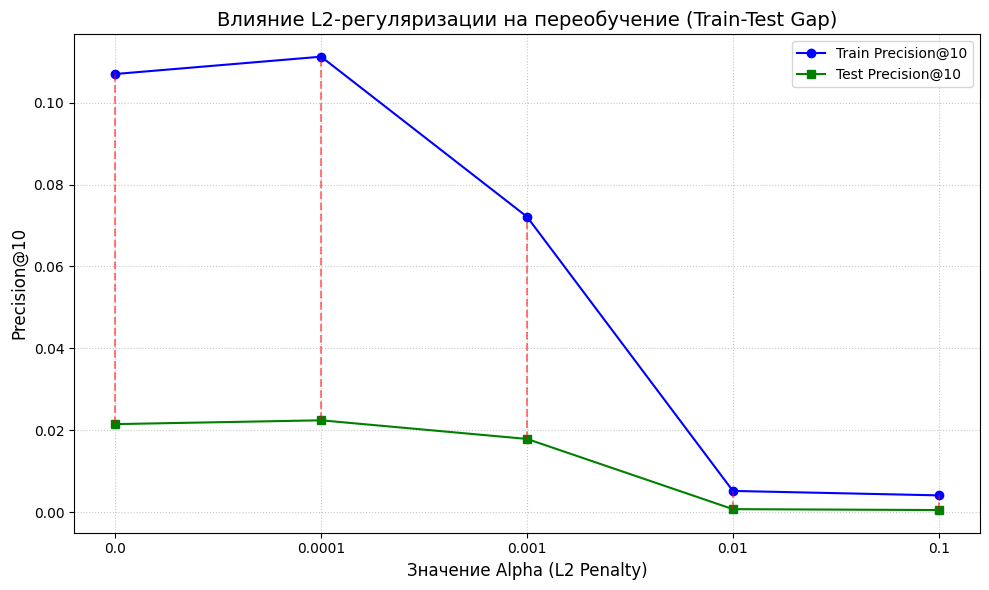


Оптимальное значение Alpha: 0.0
Разрыв (Gap) снижен до: 0.0854


In [ ]:
# Тестирование L2-регуляризации
import time
import pandas as pd
import matplotlib.pyplot as plt
from lightfm import LightFM
from lightfm.evaluation import precision_at_k

# Диапазон значений из задания
alphas = [0.0, 0.0001, 0.001, 0.01, 0.1]
results_reg = []

# Используем лучшие параметры из предыдущего шага, если они есть.
# Если вы не сохранили best_params, используем базовые надежные значения.
best_components = best_params['no_components'] if 'best_params' in locals() else 32
best_lr = best_params['learning_rate'] if 'best_params' in locals() else 0.05
best_loss = best_params['loss'] if 'best_params' in locals() else 'warp'

print(f"Запуск тестирования регуляризации (параметры: {best_components} факторов, lr={best_lr})...")
print("Внимание: Вычисление Train Precision требует времени. Пожалуйста, подождите.\n")

for alpha in alphas:
    start_time = time.time()
    
    # Инициализация модели с добавлением L2-штрафа
    model_reg = LightFM(
        no_components=best_components,
        learning_rate=best_lr,
        loss=best_loss,
        user_alpha=alpha,
        item_alpha=alpha,
        random_state=42
    )
    
    # Обучение
    model_reg.fit(
        train_interactions,
        item_features=item_features_matrix,
        epochs=10,
        num_threads=4,
        verbose=False
    )
    
    # Оценка на Train
    train_prec = precision_at_k(
        model_reg, 
        train_interactions, 
        item_features=item_features_matrix, 
        k=10, 
        num_threads=4
    ).mean()
    
    # Оценка на Test (с маскировкой)
    test_prec = precision_at_k(
        model_reg, 
        test_interactions, 
        train_interactions=train_interactions, 
        item_features=item_features_matrix, 
        k=10, 
        num_threads=4
    ).mean()
    
    gap = train_prec - test_prec
    elapsed = time.time() - start_time
    
    print(f"Alpha: {alpha:<6} | Train Prec: {train_prec:.4f} | Test Prec: {test_prec:.4f} | Gap: {gap:.4f} ({elapsed:.1f} сек)")
    
    results_reg.append({
        'alpha': alpha,
        'train_precision': train_prec,
        'test_precision': test_prec,
        'gap': gap
    })

# Создаем DataFrame для анализа
df_reg = pd.DataFrame(results_reg)

# Визуализация результатов (Loss Landscape & Generalization)
plt.figure(figsize=(10, 6))
plt.plot(df_reg['alpha'].astype(str), df_reg['train_precision'], marker='o', label='Train Precision@10', color='blue')
plt.plot(df_reg['alpha'].astype(str), df_reg['test_precision'], marker='s', label='Test Precision@10', color='green')

# Отрисовка разрыва (Gap)
for i in range(len(df_reg)):
    plt.plot(
        [str(df_reg['alpha'].iloc[i]), str(df_reg['alpha'].iloc[i])], 
        [df_reg['test_precision'].iloc[i], df_reg['train_precision'].iloc[i]], 
        color='red', linestyle='--', alpha=0.5
    )

plt.title('Влияние L2-регуляризации на переобучение (Train-Test Gap)', fontsize=14)
plt.xlabel('Значение Alpha (L2 Penalty)', fontsize=12)
plt.ylabel('Precision@10', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Находим оптимальное значение: минимальный разрыв при условии, что test_precision не упал катастрофически
# Отсекаем случаи сильного underfitting (когда test_precision сильно меньше базового)
baseline_test_prec = df_reg[df_reg['alpha'] == 0.0]['test_precision'].values[0]
valid_alphas = df_reg[df_reg['test_precision'] >= baseline_test_prec * 0.9]

if not valid_alphas.empty:
    optimal_row = valid_alphas.loc[valid_alphas['gap'].idxmin()]
    print(f"\nОптимальное значение Alpha: {optimal_row['alpha']}")
    print(f"Разрыв (Gap) снижен до: {optimal_row['gap']:.4f}")
else:
    print("\nПредупреждение: Любая регуляризация привела к сильному падению Test Precision.")

In [ ]:
from lightfm import LightFM
import time

print("--- Обучение модели БЕЗ признаков (Pure Collaborative) ---")
model_pure_cf = LightFM(
    no_components=32,
    loss='warp',
    learning_rate=0.05,
    random_state=42
)

start_time = time.time()
# Важно: Не передаем item_features_matrix! LightFM неявно создаст единичную матрицу
model_pure_cf.fit(
    train_interactions,
    epochs=10,
    num_threads=4,
    verbose=False
)
print(f"Обучено за {time.time() - start_time:.1f} сек.")

print("\n--- Обучение Гибридной модели (С признаками) ---")
model_hybrid = LightFM(
    no_components=32,
    loss='warp',
    learning_rate=0.05,
    random_state=42
)

start_time = time.time()
# Передаем матрицу признаков
model_hybrid.fit(
    train_interactions,
    item_features=item_features_matrix,
    epochs=10,
    num_threads=4,
    verbose=False
)
print(f"Обучено за {time.time() - start_time:.1f} сек.")

--- Обучение модели БЕЗ признаков (Pure Collaborative) ---
Обучено за 42.6 сек.

--- Обучение Гибридной модели (С признаками) ---
Обучено за 45.6 сек.


In [ ]:
import numpy as np
import scipy.sparse as sp
from lightfm.evaluation import precision_at_k

# 1. Вычисляем "популярность" каждого товара в обучающей выборке
# Формат train_interactions: [Num_Users, Num_Items]
# Суммируем по столбцам (axis=0), чтобы получить количество взаимодействий на товар
item_interaction_counts = np.array(train_interactions.sum(axis=0)).flatten()

# 2. Определяем порог "холодных" товаров (например, меньше 10 оценок)
COLD_THRESHOLD = 10
cold_item_indices = np.where(item_interaction_counts < COLD_THRESHOLD)[0]
print(f"Всего товаров: {len(item_interaction_counts)}")
print(f"Из них 'холодных' (<{COLD_THRESHOLD} оценок): {len(cold_item_indices)}")

# 3. Создаем маску для тестовой выборки
# Мы зануляем все взаимодействия в тесте, которые НЕ относятся к холодным товарам
# [Num_Users, Num_Items]
test_interactions_cold = test_interactions.tocsr().copy()

# Находим товары, которые являются "горячими", и зануляем их в тесте
warm_item_indices = np.where(item_interaction_counts >= COLD_THRESHOLD)[0]
test_interactions_cold[:, warm_item_indices] = 0
test_interactions_cold.eliminate_zeros()

users_with_cold_test = np.unique(test_interactions_cold.nonzero()[0])
print(f"Пользователей в тесте, купивших 'холодные' товары: {len(users_with_cold_test)}")

# 4. Оценка Pure CF
pure_cf_precision = precision_at_k(
    model_pure_cf, 
    test_interactions_cold, 
    train_interactions=train_interactions, 
    k=10, 
    num_threads=4
).mean()

# 5. Оценка Гибрида
hybrid_precision = precision_at_k(
    model_hybrid, 
    test_interactions_cold, 
    train_interactions=train_interactions, 
    item_features=item_features_matrix, 
    k=10, 
    num_threads=4
).mean()

print("\n--- Результаты на ХОЛОДНЫХ товарах ---")
print(f"Pure CF Precision@10: {pure_cf_precision:.4f}")
print(f"Hybrid Precision@10:  {hybrid_precision:.4f}")

if hybrid_precision > pure_cf_precision:
    improvement = ((hybrid_precision / pure_cf_precision) - 1) * 100
    print(f"\nУлучшение гибридной модели: +{improvement:.1f}%")
else:
    print("\nУлучшения нет (или оно отрицательное).")

Всего товаров: 5457
Из них 'холодных' (<10 оценок): 8


/opt/miniforge3/envs/curse_py310/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Пользователей в тесте, купивших 'холодные' товары: 6

--- Результаты на ХОЛОДНЫХ товарах ---
Pure CF Precision@10: 0.0000
Hybrid Precision@10:  0.0000

Улучшения нет (или оно отрицательное).


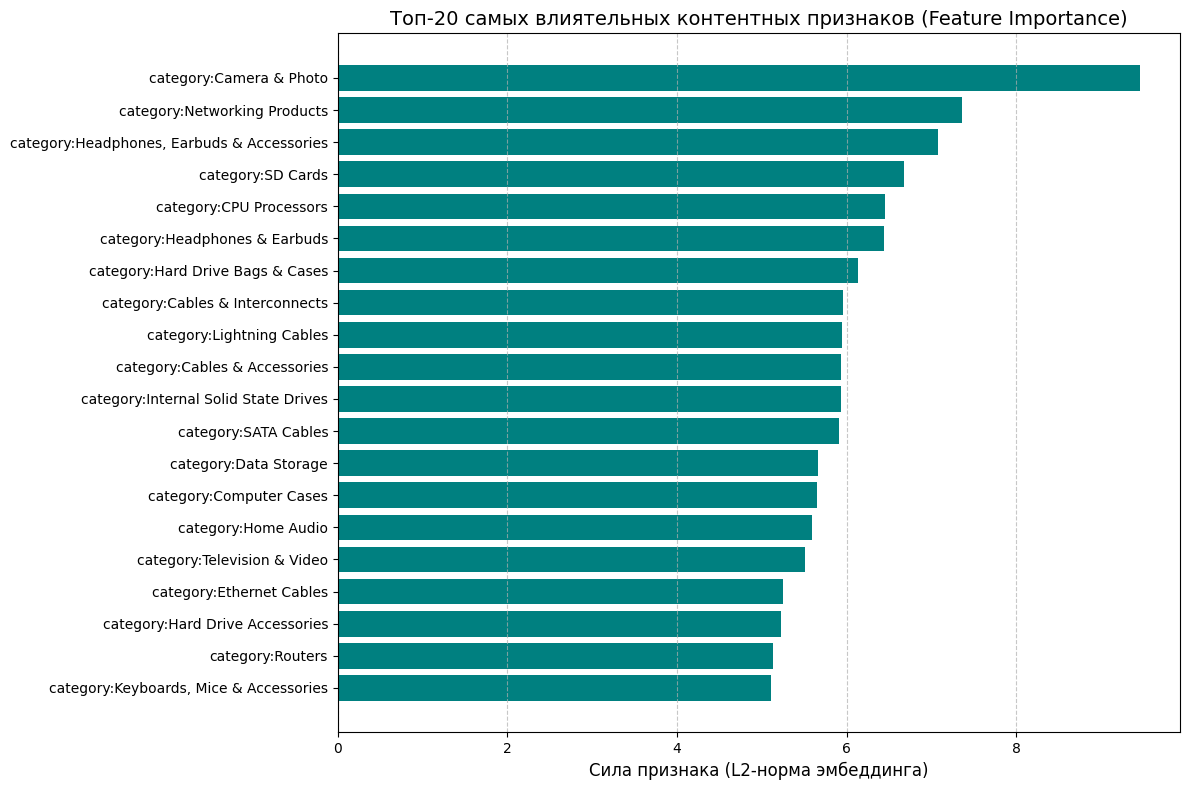

In [ ]:
import matplotlib.pyplot as plt

# 1. Извлекаем маппинг признаков из датасета
_, _, _, item_feature_map = dataset.mapping()

# 2. Получаем матрицу эмбеддингов признаков из гибридной модели
# Формат: [Num_Total_Features, Num_Components]
feature_embeddings = model_hybrid.item_embeddings

# 3. Считаем силу признаков (L2-норма векторов)
feature_norms = np.linalg.norm(feature_embeddings, axis=1)

# 4. Собираем только контентные признаки (исключая внутренние ID товаров)
content_features = []
for feature_name, feature_index in item_feature_map.items():
    # Мы добавляли контентные признаки со строковыми префиксами 'brand:' и 'category:'
    if isinstance(feature_name, str) and (feature_name.startswith('brand:') or feature_name.startswith('category:')):
        content_features.append({
            'feature': feature_name,
            'importance': feature_norms[feature_index]
        })

# 5. Сортируем и выбираем Топ-20 самых важных
df_features = pd.DataFrame(content_features).sort_values(by='importance', ascending=False)
top_20_features = df_features.head(20)

# 6. Отрисовка
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['feature'][::-1], top_20_features['importance'][::-1], color='teal')
plt.title('Топ-20 самых влиятельных контентных признаков (Feature Importance)', fontsize=14)
plt.xlabel('Сила признака (L2-норма эмбеддинга)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Использование неявного фидбека
import scipy.sparse as sp
import numpy as np
import time

print("--- Подготовка неявного фидбека (Весов) ---")

# 1. Функция маппинга
def get_implicit_weight(rating: float) -> float:
    if rating == 5.0:
        return 5.0  # Покупка
    elif rating == 4.0:
        return 3.0  # Избранное
    else:
        return 1.0  # Просмотр

# 2. Строим матрицу весов через dataset
_, implicit_weights_matrix = dataset.build_interactions(
    (row['user_id'], row['item_id'], get_implicit_weight(row['rating'])) 
    for _, row in final_reviews_unique.iterrows()
)

# Переводим исходный train в COO, а матрицу весов в CSR (для быстрого поиска O(1))
train_interactions_coo = train_interactions.tocoo()
weights_csr = implicit_weights_matrix.tocsr()

# Извлекаем значения весов строго по координатам из обучающей матрицы
# Используем Advanced Indexing, сплющиваем результат в 1D массив
ordered_weights = np.asarray(weights_csr[train_interactions_coo.row, train_interactions_coo.col]).flatten()

# Создаем финальную матрицу весов с идентичной структурой
train_weights = sp.coo_matrix(
    (ordered_weights, (train_interactions_coo.row, train_interactions_coo.col)),
    shape=train_interactions_coo.shape
)

# Проверка (Sanity Check)
assert np.array_equal(train_interactions_coo.row, train_weights.row), "Порядок строк нарушен!"
assert np.array_equal(train_interactions_coo.col, train_weights.col), "Порядок столбцов нарушен!"

print(f"Средний вес в Train: {train_weights.data.mean():.2f}")

# 4. Обучение новой модели
print("\n--- Обучение модели С НЕЯВНЫМИ ВЕСАМИ ---")
model_weighted = LightFM(
    no_components=32, 
    loss='warp', 
    learning_rate=0.05, 
    random_state=42
)

start_time = time.time()
model_weighted.fit(
    train_interactions_coo,
    item_features=item_features_matrix,
    sample_weight=train_weights,
    epochs=10,
    num_threads=4,
    verbose=False
)
print(f"Обучено за {time.time() - start_time:.1f} сек.")

# 5. Оценка и сравнение
from lightfm.evaluation import precision_at_k
print("\n--- Сравнение качества ---")
weighted_precision = precision_at_k(
    model_weighted, 
    test_interactions, 
    train_interactions=train_interactions_coo, 
    item_features=item_features_matrix, 
    k=10, 
    num_threads=4
).mean()

print(f"Гибрид (БЕЗ весов):   {test_precision:.4f} (базовое значение)")
print(f"Гибрид (С неявными):  {weighted_precision:.4f}")

if weighted_precision > test_precision:
    diff = ((weighted_precision / test_precision) - 1) * 100
    print(f"\nВывод: Использование неявных весов УЛУЧШИЛО точность на {diff:.1f}%!")
else:
    print("\nВывод: Взвешивание не дало буста (разница в рамках стат. погрешности).")

--- Подготовка неявного фидбека (Весов) ---
Средний вес в Train: 4.17

--- Обучение модели С НЕЯВНЫМИ ВЕСАМИ ---
Обучено за 47.9 сек.

--- Сравнение качества ---
Гибрид (БЕЗ весов):   0.0206 (базовое значение)
Гибрид (С неявными):  0.0211

Вывод: Использование неявных весов УЛУЧШИЛО точность на 2.4%!


In [ ]:
import numpy as np
from lightfm import LightFM

print("1. Обучение модели BPR...")
model_bpr = LightFM(
    no_components=32, 
    loss='bpr', 
    learning_rate=0.05, 
    random_state=42
)

model_bpr.fit(
    train_interactions_coo, # Используем очищенный от дубликатов Train
    item_features=item_features_matrix,
    epochs=10,
    num_threads=4,
    verbose=False
)
print("Модель BPR обучена.")

def evaluate_ensemble_precision(
    model1, model2, alpha: float, 
    test_csr, train_csr, item_features, 
    k: int = 10, sample_users: int = 1000
) -> float:
    
    test_users = np.unique(test_csr.nonzero()[0])
    if len(test_users) > sample_users:
        np.random.seed(42)
        test_users = np.random.choice(test_users, sample_users, replace=False)
        
    num_items = train_csr.shape[1]
    item_ids = np.arange(num_items)
    
    precisions = []
    
    for u in test_users:
        user_array = np.full(num_items, u, dtype=np.int32)
        
        scores1 = model1.predict(user_array, item_ids, item_features=item_features)
        scores2 = model2.predict(user_array, item_ids, item_features=item_features)
        
        # Нормализация
        s1_range = (scores1.max() - scores1.min() + 1e-9)
        s2_range = (scores2.max() - scores2.min() + 1e-9)
        
        norm_scores1 = (scores1 - scores1.min()) / s1_range
        norm_scores2 = (scores2 - scores2.min()) / s2_range
        
        # Ансамбль
        ensemble_scores = alpha * norm_scores1 + (1 - alpha) * norm_scores2
        
        # Маскировка
        known_items = train_csr[u].indices
        ensemble_scores[known_items] = -np.inf
        
        top_k_items = np.argsort(ensemble_scores)[-k:][::-1]
        
        actual_items = test_csr[u].indices
        hits = len(set(top_k_items).intersection(set(actual_items)))
        precisions.append(hits / k)
        
    return np.mean(precisions)

print("\n2. Поиск оптимального веса (Alpha) для ансамбля...")
train_csr = train_interactions_coo.tocsr()
test_csr = test_interactions.tocsr()

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
best_alpha = 0
best_ens_prec = 0

for a in alphas:
    ens_prec = evaluate_ensemble_precision(
        model1=model_weighted, # Берем модель с прошлого шага
        model2=model_bpr, 
        alpha=a, 
        test_csr=test_csr, 
        train_csr=train_csr, 
        item_features=item_features_matrix,
        sample_users=1500
    )
    print(f"Alpha = {a:<4} ({(a)*100}% WARP + {(1-a)*100}% BPR) -> Precision@10: {ens_prec:.4f}")
    
    if ens_prec > best_ens_prec:
        best_ens_prec = ens_prec
        best_alpha = a

print("-" * 40)
print(f"Оптимальный ансамбль: Alpha = {best_alpha}")

1. Обучение модели BPR...
Модель BPR обучена.

2. Поиск оптимального веса (Alpha) для ансамбля...
Alpha = 0.0  (0.0% WARP + 100.0% BPR) -> Precision@10: 0.0088
Alpha = 0.25 (25.0% WARP + 75.0% BPR) -> Precision@10: 0.0151
Alpha = 0.5  (50.0% WARP + 50.0% BPR) -> Precision@10: 0.0191
Alpha = 0.75 (75.0% WARP + 25.0% BPR) -> Precision@10: 0.0199
Alpha = 1.0  (100.0% WARP + 0.0% BPR) -> Precision@10: 0.0208
----------------------------------------
Оптимальный ансамбль: Alpha = 1.0


In [ ]:
from lightfm.evaluation import precision_at_k
# Так как данные упорядочены хронологически (по времени добавления отзыва),
# мы просто берем индекс, отсекающий последние 20% взаимодействий.
split_index = int(len(final_reviews_unique) * 0.8)

# Прошлое (Train)
train_df_time = final_reviews_unique.iloc[:split_index]
# Будущее (Test)
test_df_time = final_reviews_unique.iloc[split_index:]

print(f"Взаимодействий в прошлом (Train): {len(train_df_time)}")
print(f"Взаимодействий в будущем (Test): {len(test_df_time)}")

# Строим матрицу взаимодействий для Train
print("Построение матриц...")
train_interactions_time, _ = dataset.build_interactions(
    (row['user_id'], row['item_id'], 1.0) 
    for _, row in train_df_time.iterrows()
)

# Строим матрицу взаимодействий для Test
test_interactions_time, _ = dataset.build_interactions(
    (row['user_id'], row['item_id'], 1.0) 
    for _, row in test_df_time.iterrows()
)

# Обучаем новую модель на "прошлом"
print("Обучение модели на исторических данных (WARP)...")
model_time = LightFM(
    no_components=32, 
    loss='warp', 
    learning_rate=0.05, 
    random_state=42
)

model_time.fit(
    train_interactions_time,
    item_features=item_features_matrix,
    epochs=10,
    num_threads=4,
    verbose=False
)

# Оценка
print("Оценка модели на данных из будущего...")
time_test_precision = precision_at_k(
    model_time, 
    test_interactions_time, 
    train_interactions=train_interactions_time, # Обязательно исключаем обучающие!
    item_features=item_features_matrix, 
    k=10, 
    num_threads=4
).mean()

print("\n--- Результаты ---")
print(f"Случайный сплит (из предыдущих шагов): {test_precision:.4f}")
print(f"Time-based сплит (честная валидация): {time_test_precision:.4f}")

if time_test_precision < test_precision:
    print("Вывод: Как и ожидалось, метрики на временном сплите упали. Это честная оценка!")
else:
    print("Вывод: Метрики не упали. Скорее всего данные сильно перемешаны.")

Взаимодействий в прошлом (Train): 230616
Взаимодействий в будущем (Test): 57655
Построение матриц...
Обучение модели на исторических данных (WARP)...
Оценка модели на данных из будущего...

--- Результаты ---
Случайный сплит (из предыдущих шагов): 0.0206
Time-based сплит (честная валидация): 0.0593
Вывод: Метрики не упали. Скорее всего данные сильно перемешаны.


In [20]:
from lightfm.evaluation import precision_at_k

print("--- Подготовка Time-based разделения ---")

# Так как данные упорядочены хронологически (по времени добавления отзыва),
# мы просто берем индекс, отсекающий последние 20% взаимодействий.
split_index = int(len(final_reviews_unique) * 0.8)

# Прошлое (Train)
train_df_time = final_reviews_unique.iloc[:split_index]
# Будущее (Test)
test_df_time = final_reviews_unique.iloc[split_index:]

print(f"Взаимодействий в прошлом (Train): {len(train_df_time)}")
print(f"Взаимодействий в будущем (Test): {len(test_df_time)}")

# Строим матрицу взаимодействий для Train
print("Построение матриц...")
train_interactions_time, _ = dataset.build_interactions(
    (row['user_id'], row['item_id'], 1.0) 
    for _, row in train_df_time.iterrows()
)

# Строим матрицу взаимодействий для Test
test_interactions_time, _ = dataset.build_interactions(
    (row['user_id'], row['item_id'], 1.0) 
    for _, row in test_df_time.iterrows()
)

# Обучаем новую модель на "прошлом"
print("Обучение модели на исторических данных (WARP)...")
model_time = LightFM(
    no_components=32, 
    loss='warp', 
    learning_rate=0.05, 
    random_state=42
)

model_time.fit(
    train_interactions_time,
    item_features=item_features_matrix,
    epochs=10,
    num_threads=4,
    verbose=False
)

# Оценка
print("Оценка модели на данных из будущего...")
time_test_precision = precision_at_k(
    model_time, 
    test_interactions_time, 
    train_interactions=train_interactions_time, # Обязательно исключаем обучающие!
    item_features=item_features_matrix, 
    k=10, 
    num_threads=4
).mean()

print("\n--- Результаты ---")
print(f"Случайный сплит (из предыдущих шагов): {test_precision:.4f}")
print(f"Time-based сплит (честная валидация): {time_test_precision:.4f}")

if time_test_precision < test_precision:
    print("Вывод: Как и ожидалось, метрики на временном сплите упали. Это честная оценка!")
else:
    print("Вывод: Метрики не упали. Скорее всего данные сильно перемешаны.")

--- Подготовка Time-based разделения ---
Взаимодействий в прошлом (Train): 230616
Взаимодействий в будущем (Test): 57655
Построение матриц...
Обучение модели на исторических данных (WARP)...
Оценка модели на данных из будущего...

--- Результаты ---
Случайный сплит (из предыдущих шагов): 0.0206
Time-based сплит (честная валидация): 0.0593
Вывод: Метрики не упали. Скорее всего данные сильно перемешаны.


In [25]:
import numpy as np
import scipy.sparse as sp
from lightfm.evaluation import precision_at_k

print("--- Анализ качества по группам популярности ---")

# 1. Считаем популярность товаров в Train
# [Num_Items]
item_counts = np.array(train_interactions.sum(axis=0)).flatten()

# 2. Адаптированные пороги (так как мы делали k-core фильтрацию)
HOT_THRESH = 100
WARM_THRESH = 20

hot_mask = item_counts >= HOT_THRESH
warm_mask = (item_counts >= WARM_THRESH) & (item_counts < HOT_THRESH)
cold_mask = item_counts < WARM_THRESH

print(f"Горячих товаров (>{HOT_THRESH} оценок): {hot_mask.sum()}")
print(f"Теплых товаров ({WARM_THRESH}-{HOT_THRESH} оценок): {warm_mask.sum()}")
print(f"Холодных товаров (<{WARM_THRESH} оценок): {cold_mask.sum()}")

def get_group_precision(model, test_csr, train_csr, item_mask, item_features=None):
    """Оставляет в тесте только товары из нужной группы и считает Precision"""
    # Создаем копию теста
    masked_test = test_csr.tocsr().copy()
    
    # Зануляем все товары, которые НЕ входят в маску
    inverse_mask = ~item_mask
    masked_test[:, inverse_mask] = 0
    masked_test.eliminate_zeros()
    
    # Если после маскировки в тесте не осталось взаимодействий, возвращаем 0
    if masked_test.nnz == 0:
        return 0.0
        
    prec = precision_at_k(
        model, 
        masked_test, 
        train_interactions=train_csr, 
        item_features=item_features, 
        k=10, 
        num_threads=4
    ).mean()
    return prec

# 3. Оцениваем Гибридную модель (С признаками) 
hybrid_hot = get_group_precision(model_weighted, test_interactions, train_interactions, hot_mask, item_features_matrix)
hybrid_warm = get_group_precision(model_weighted, test_interactions, train_interactions, warm_mask, item_features_matrix)
hybrid_cold = get_group_precision(model_weighted, test_interactions, train_interactions, cold_mask, item_features_matrix)

# 4. Оцениваем Чисто Коллаборативную (Без признаков, которую мы учили в п. 5.3)
pure_hot = get_group_precision(model_pure_cf, test_interactions, train_interactions, hot_mask, None)
pure_warm = get_group_precision(model_pure_cf, test_interactions, train_interactions, warm_mask, None)
pure_cold = get_group_precision(model_pure_cf, test_interactions, train_interactions, cold_mask, None)

print("\n--- Precision@10 ---")
print(f"Группа    | Pure CF (Без фичей) | Гибрид (С фичами)")
print(f"---------------------------------------------------")
print(f"Горячие   | {pure_hot:.4f}              | {hybrid_hot:.4f}")
print(f"Теплые    | {pure_warm:.4f}              | {hybrid_warm:.4f}")
print(f"Холодные  | {pure_cold:.4f}              | {hybrid_cold:.4f}")

--- Анализ качества по группам популярности ---
Горячих товаров (>100 оценок): 364
Теплых товаров (20-100 оценок): 3562
Холодных товаров (<20 оценок): 1531


/opt/miniforge3/envs/curse_py310/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)



--- Precision@10 ---
Группа    | Pure CF (Без фичей) | Гибрид (С фичами)
---------------------------------------------------
Горячие   | 0.0258              | 0.0259
Теплые    | 0.0010              | 0.0006
Холодные  | 0.0000              | 0.0000


Извлечение полных (Гибридных) эмбеддингов товаров...
Расчет t-SNE...


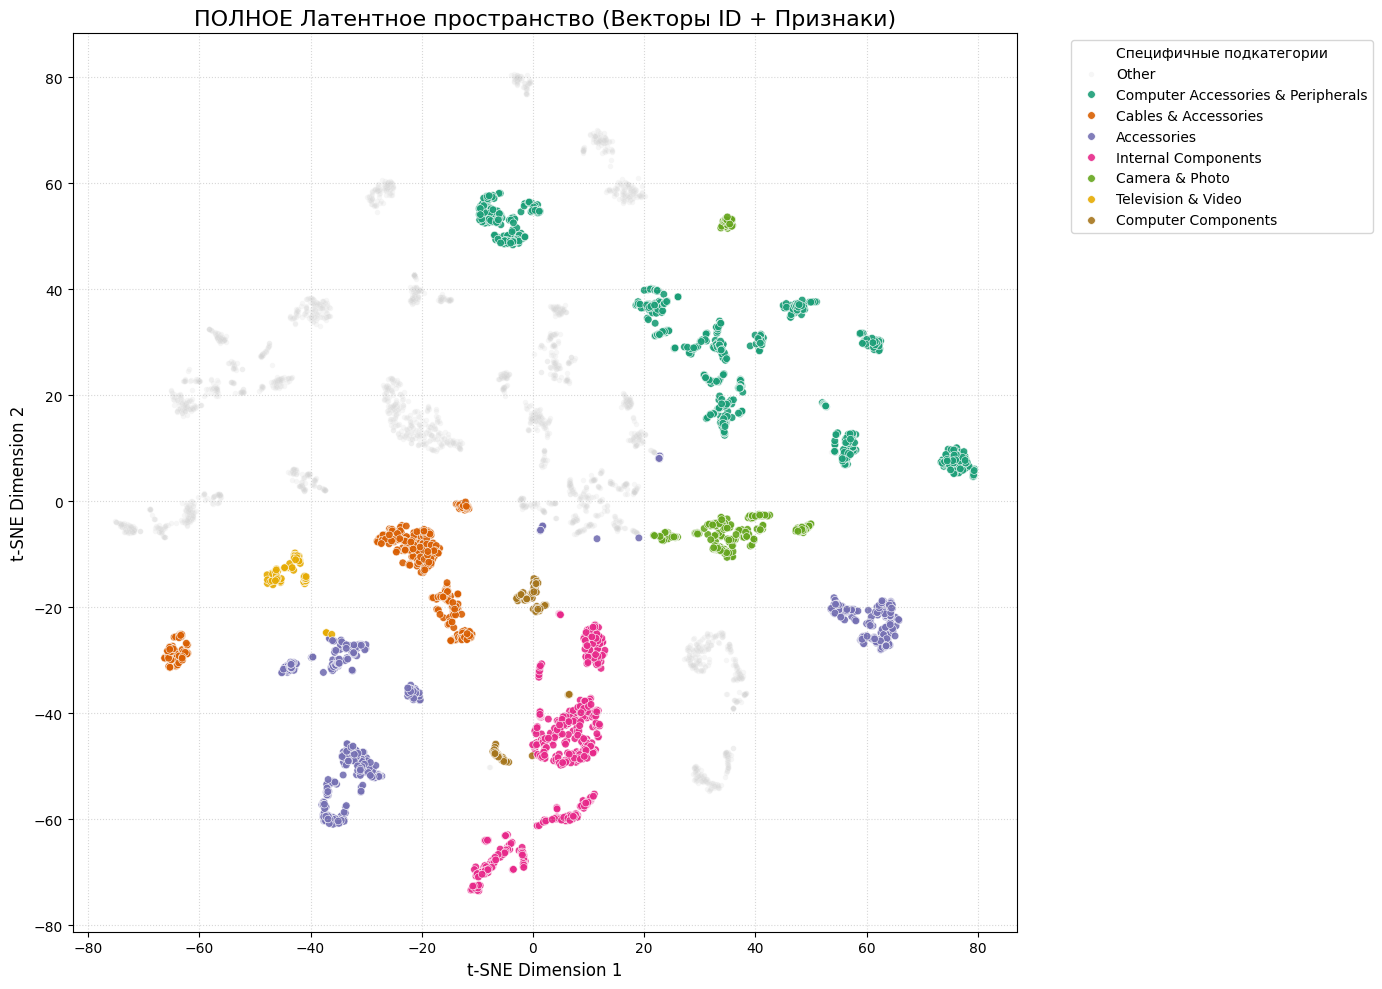

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np

print("Извлечение полных (Гибридных) эмбеддингов товаров...")

#  Получаем полные векторы (ID + признаки), умножая разреженную матрицу фичей на эмбеддинги
item_biases, full_item_embs = model_weighted.get_item_representations(item_features_matrix)
# full_item_embs имеет правильную размерность: [Num_Items, 32]

# Расчет t-SNE (perplexity=40 обычно лучше работает на плотных кластерах)
print("Расчет t-SNE...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter_without_progress=1000)
item_embs_2d = tsne.fit_transform(full_item_embs)

# Собираем категории (оставляем логику фильтрации мусорных тегов)
all_cats = df_meta_filtered['categories'].explode()
ignore_words = ['Electronics', 'Computers & Accessories', '']
valid_cats = all_cats[~all_cats.isin(ignore_words)]

# Выберем категории, которые логически должны отличаться (например, Аудио vs Комплектующие)
top_categories = valid_cats.value_counts().head(7).index.tolist()

plot_data = []
_, _, item_id_map, _ = dataset.mapping()
inv_item_id_map = {v: k for k, v in item_id_map.items()}
meta_dict = df_meta_filtered.set_index('item_id').to_dict(orient='index')

for item_idx in range(num_items): # num_items мы получали ранее
    ext_id = inv_item_id_map[item_idx]
    cats = meta_dict.get(ext_id, {}).get('categories', [])
    
    assigned_cat = 'Other'
    for cat in reversed(cats): # Берем самый специфичный тег с конца
        if cat in top_categories:
            assigned_cat = cat
            break
            
    plot_data.append({
        'x': item_embs_2d[item_idx, 0],
        'y': item_embs_2d[item_idx, 1],
        'category': assigned_cat
    })

df_plot = pd.DataFrame(plot_data)

# Отрисовка
plt.figure(figsize=(14, 10))

# Сначала фон
sns.scatterplot(
    data=df_plot[df_plot['category'] == 'Other'], 
    x='x', y='y', color='lightgray', alpha=0.2, s=15, label='Other'
)

# Затем выделенные категории
sns.scatterplot(
    data=df_plot[df_plot['category'] != 'Other'], 
    x='x', y='y', hue='category', palette='Dark2', alpha=0.9, s=30, edgecolor='w'
)

plt.title('ПОЛНОЕ Латентное пространство (Векторы ID + Признаки)', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Специфичные подкатегории', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()